# 🎓 300K Student Performance Prediction Dataset - Full EDA & Data Processing
**Goal:** Explore every column, understand patterns, find relationships with `pass_fail`, and prepare data for logistic regression from scratch.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.style.use('seaborn-v0_8')
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [3]:
df = pd.read_csv('student_performance_prediction_dataset.csv')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (300000, 25)


,student_id,age,gender,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,notes_quality_score,time_management_score,motivation_level,mental_health_score,screen_time,social_media_hours,family_income,parent_education,internet_access,device_type,school_type,extracurriculars,final_grade,grade_category,pass_fail
0,1,21,Male,1.65,79.15,8.23,96.05,7.72,1.87,1.45,6.81,7.32,9.05,7.76,1.55,4.02,Medium,Master,Yes,Mobile,Private,Coding Club,59.25,D,Pass
1,2,18,Male,4.46,72.53,6.14,53.02,6.75,5.63,1.89,10.00,10.00,9.81,4.23,5.46,3.27,Medium,Master,Yes,Laptop,Public,NaN,58.60,D,Pass
2,3,19,Female,6.22,98.53,6.95,78.78,10.00,7.86,1.77,6.48,3.62,10.00,7.58,0.00,2.33,Low,High School,Yes,Tablet,Private,Music,85.86,A,Pass
3,4,21,Female,1.83,97.73,8.30,76.12,7.44,2.32,1.20,6.06,5.37,5.94,4.98,5.33,1.16,Medium,Bachelor,Yes,Laptop,Public,Debate,42.12,F,Fail
4,5,17,Male,3.79,78.59,6.78,81.31,9.96,5.34,1.40,9.01,5.61,5.43,5.68,4.42,0.41,High,High School,Yes,Laptop,Private,Debate,62.87,C,Pass


In [4]:
df.info()
print("\nColumns:", df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   student_id             300000 non-null  int64  
 1   age                    300000 non-null  int64  
 2   gender                 300000 non-null  object 
 3   study_hours            300000 non-null  float64
 4   attendance             300000 non-null  float64
 5   sleep_hours            300000 non-null  float64
 6   previous_grade         300000 non-null  float64
 7   assignments_completed  300000 non-null  float64
 8   practice_tests_taken   300000 non-null  float64
 9   group_study_hours      300000 non-null  float64
 10  notes_quality_score    300000 non-null  float64
 11  time_management_score  300000 non-null  float64
 12  motivation_level       300000 non-null  float64
 13  mental_health_score    300000 non-null  float64
 14  screen_time            300000 non-nu

In [5]:
print("Missing values per column:\n", df.isnull().sum())
print(f"\nTotal duplicate rows: {df.duplicated().sum()}")

Missing values per column:
 student_id                   0
age                          0
gender                       0
study_hours                  0
attendance                   0
sleep_hours                  0
previous_grade               0
assignments_completed        0
practice_tests_taken         0
group_study_hours            0
notes_quality_score          0
time_management_score        0
motivation_level             0
mental_health_score          0
screen_time                  0
social_media_hours           0
family_income                0
parent_education             0
internet_access              0
device_type              15105
school_type                  0
extracurriculars         49981
final_grade                  0
grade_category               4
pass_fail                    0
dtype: int64

Total duplicate rows: 0


In [6]:
# === SPECIAL HANDLING FOR NaN in device_type & extracurriculars ===
print("NaN count in device_type:", df['device_type'].isnull().sum())
print("NaN count in extracurriculars:", df['extracurriculars'].isnull().sum())

# Fill NaN with meaningful category
df['device_type'] = df['device_type'].fillna('None')
df['extracurriculars'] = df['extracurriculars'].fillna('None')

print("\nAfter filling:")
print("device_type unique values:", df['device_type'].unique())
print("extracurriculars unique values:", df['extracurriculars'].unique())

NaN count in device_type: 15105
NaN count in extracurriculars: 49981

After filling:
device_type unique values: ['Mobile' 'Laptop' 'Tablet' 'None']
extracurriculars unique values: ['Coding Club' 'None' 'Music' 'Debate' 'Sports' 'Arts']


Pass/Fail Distribution:
pass_fail
Pass    180729
Fail    119271
Name: count, dtype: int64

Percentage:
pass_fail
Pass   60.24
Fail   39.76
Name: proportion, dtype: float64


/tmp/ipykernel_14184/2668516616.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='pass_fail', palette='Set2')


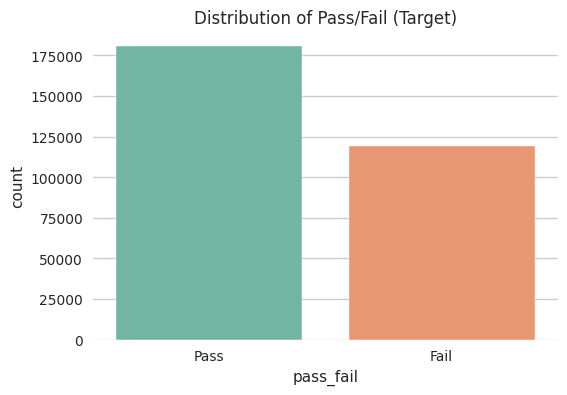

In [7]:
print("Pass/Fail Distribution:")
print(df['pass_fail'].value_counts())
print("\nPercentage:")
print(df['pass_fail'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='pass_fail', palette='Set2')
plt.title('Distribution of Pass/Fail (Target)')
plt.show()

In [8]:
# Based on your column list
numerical_cols = ['age', 'study_hours', 'attendance', 'sleep_hours', 'previous_grade',
                  'assignments_completed', 'practice_tests_taken', 'group_study_hours',
                  'notes_quality_score', 'time_management_score', 'motivation_level',
                  'mental_health_score', 'screen_time', 'social_media_hours', 'final_grade']

categorical_cols = ['gender', 'family_income', 'parent_education', 'internet_access', 'device_type',
                    'school_type', 'extracurriculars', 'grade_category']

target = 'pass_fail'

print("Numerical features:", numerical_cols)
print("Categorical features:", categorical_cols)

Numerical features: ['age', 'study_hours', 'attendance', 'sleep_hours', 'previous_grade', 'assignments_completed', 'practice_tests_taken', 'group_study_hours', 'notes_quality_score', 'time_management_score', 'motivation_level', 'mental_health_score', 'screen_time', 'social_media_hours', 'final_grade']
Categorical features: ['gender', 'family_income', 'parent_education', 'internet_access', 'device_type', 'school_type', 'extracurriculars', 'grade_category']


In [8]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,300000.00,18.00,2.00,15.00,16.00,18.00,20.00,21.00
study_hours,300000.00,4.50,1.98,0.00,3.14,4.50,5.84,12.00
attendance,300000.00,84.70,9.42,40.00,78.24,84.99,91.73,100.00
sleep_hours,300000.00,6.99,1.46,3.00,5.99,7.00,8.01,10.00
previous_grade,300000.00,69.84,14.68,20.00,59.87,69.96,80.10,100.00
assignments_completed,300000.00,7.84,1.73,0.00,6.65,8.00,9.36,10.00
practice_tests_taken,300000.00,4.02,1.96,0.00,2.66,4.00,5.35,10.00
group_study_hours,300000.00,1.53,0.94,0.00,0.83,1.50,2.17,5.84
notes_quality_score,300000.00,6.95,1.89,1.00,5.65,7.01,8.36,10.00
time_management_score,300000.00,6.46,1.93,1.00,5.14,6.49,7.85,10.00


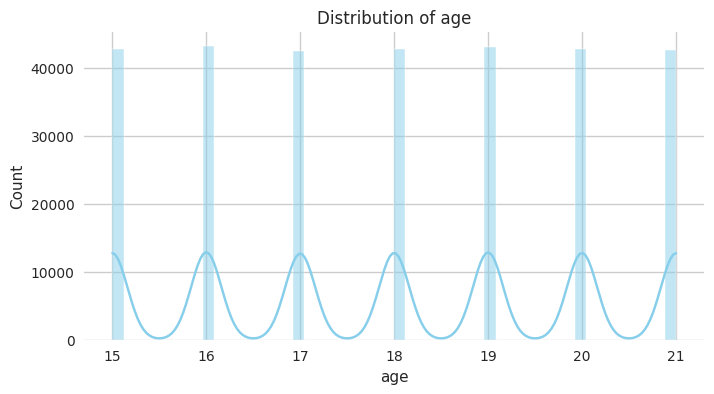

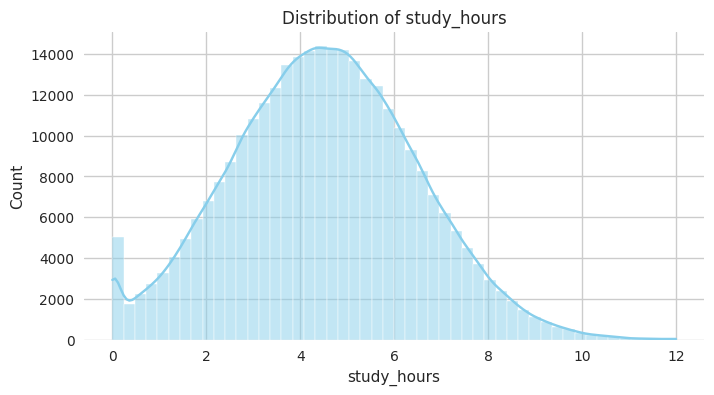

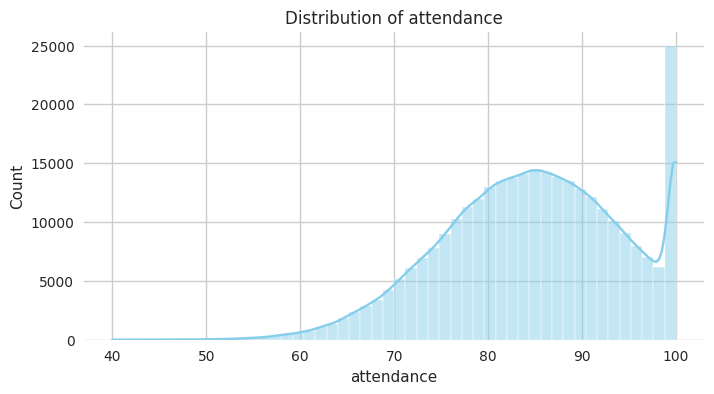

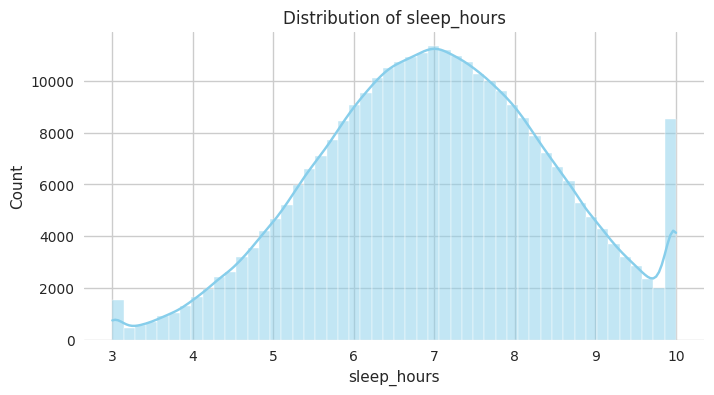

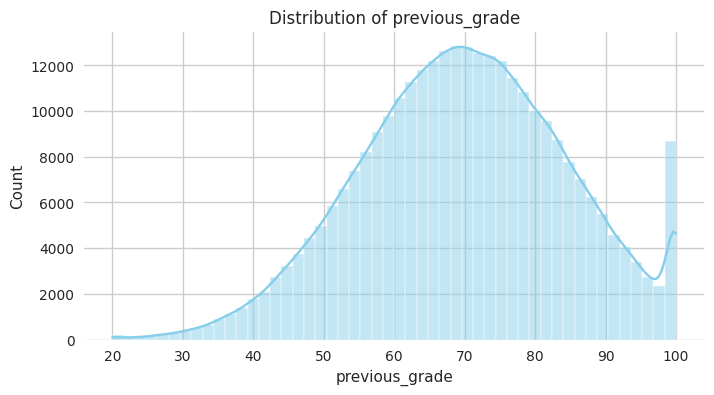

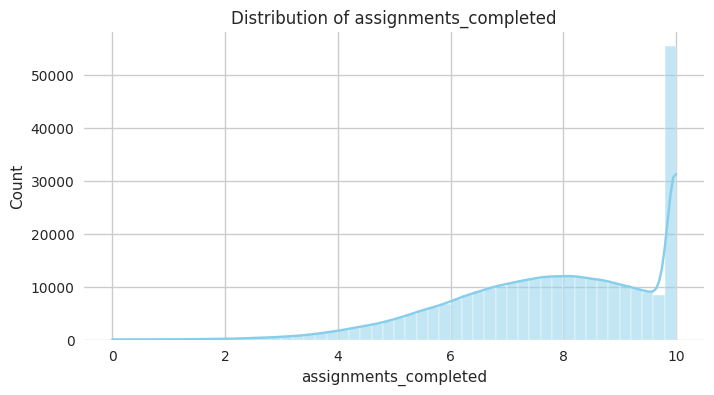

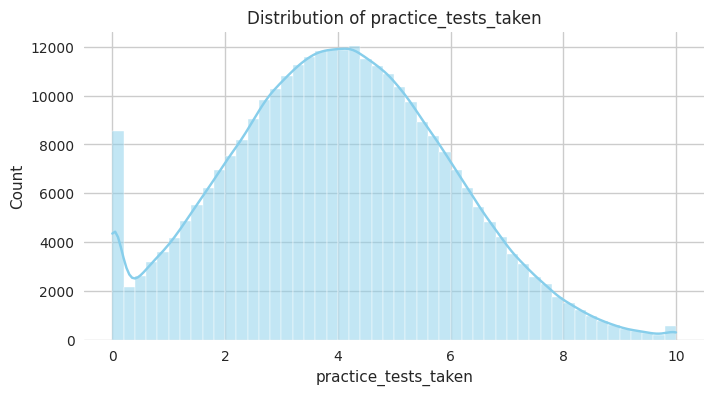

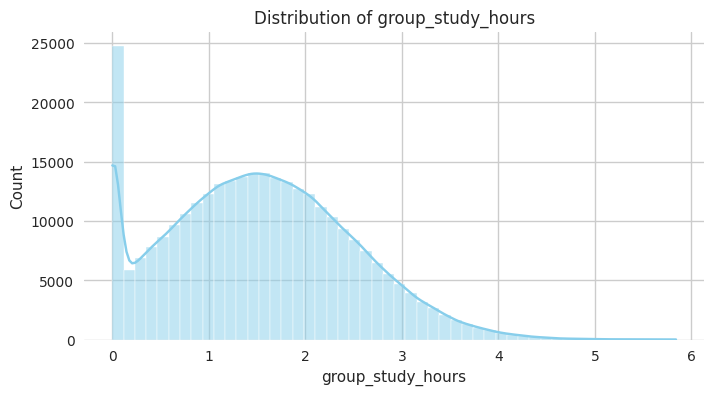

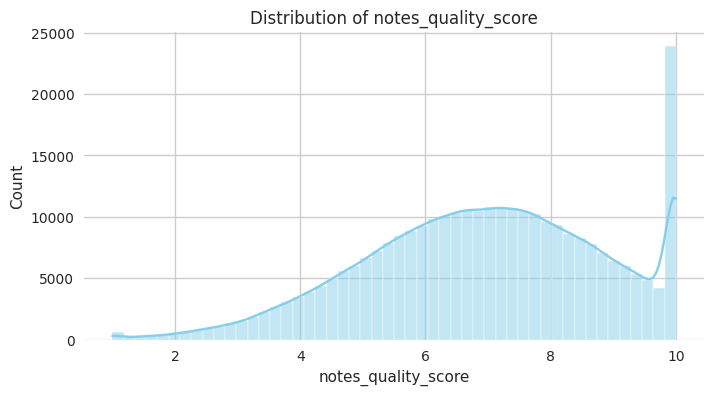

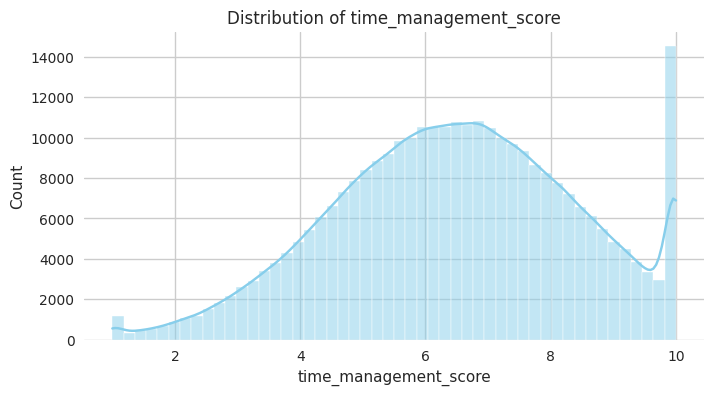

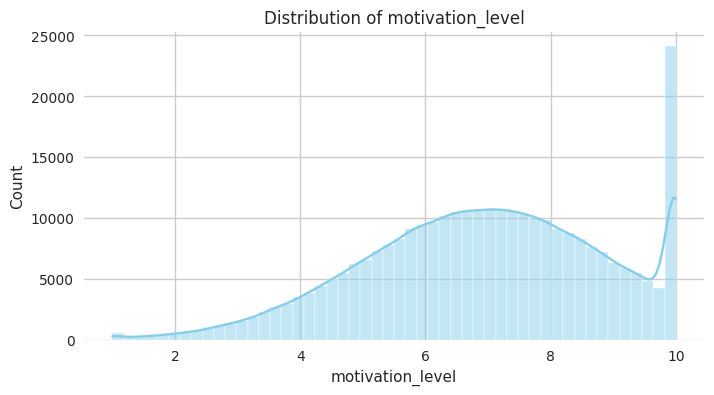

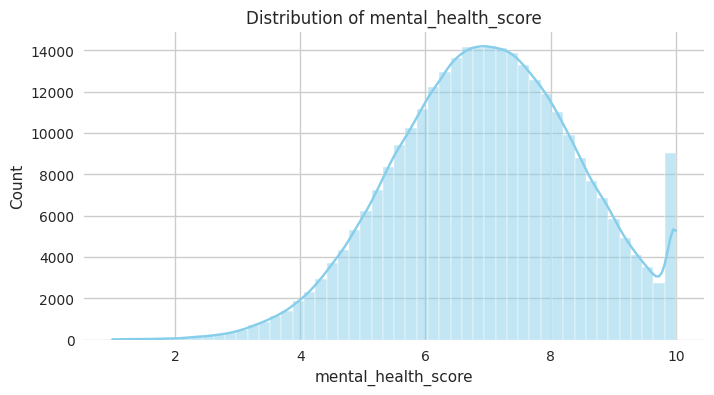

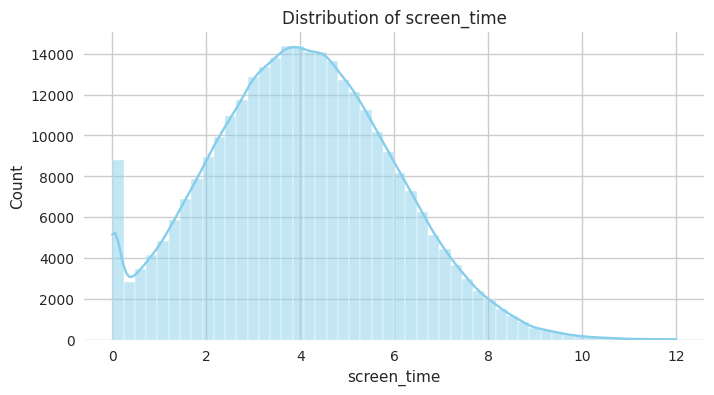

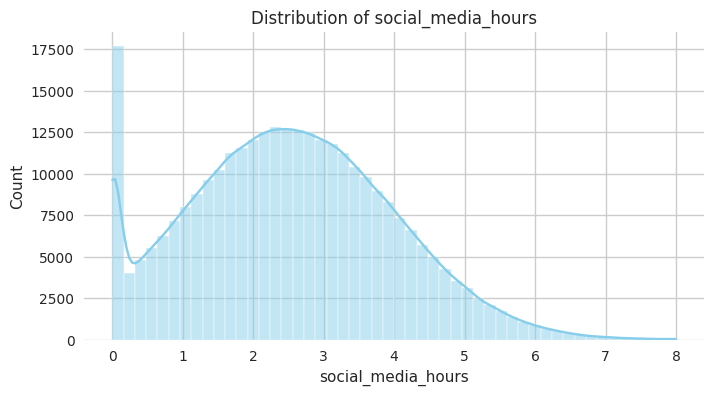

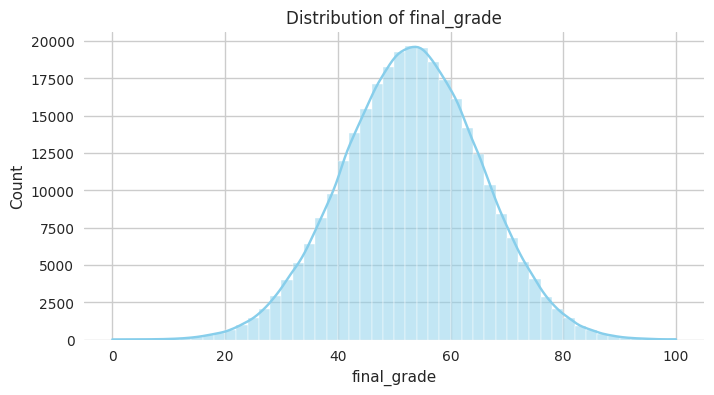

In [9]:
for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(data=df, x=col, kde=True, color='skyblue', bins=50)
    plt.title(f'Distribution of {col}')
    plt.show()

/tmp/ipykernel_28261/386563438.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


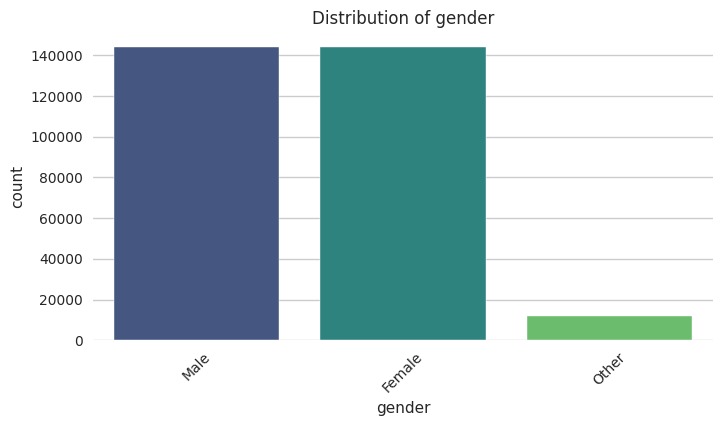

/tmp/ipykernel_28261/386563438.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


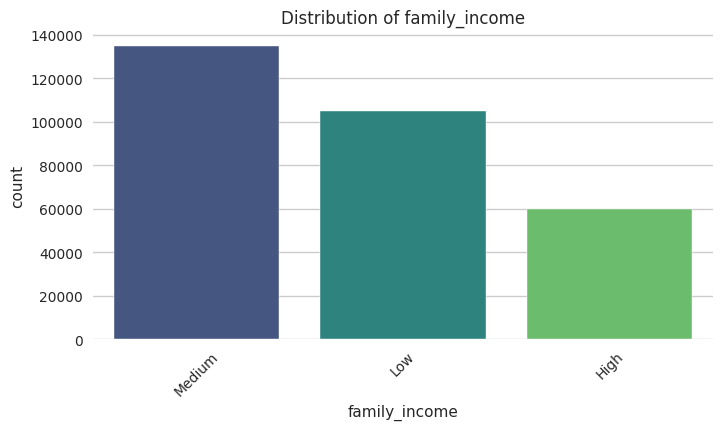

/tmp/ipykernel_28261/386563438.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


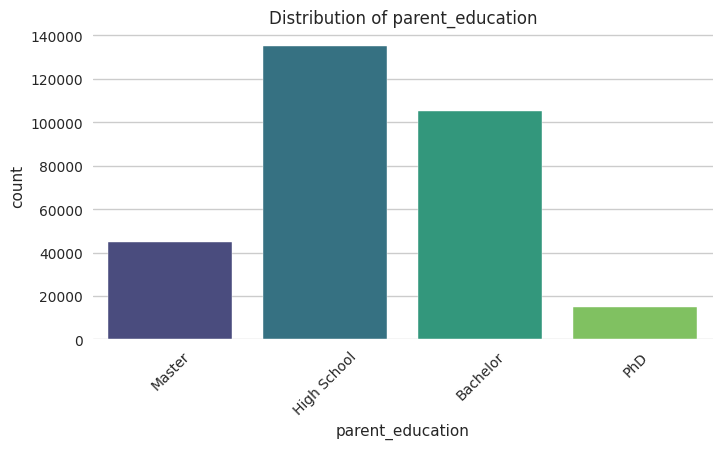

/tmp/ipykernel_28261/386563438.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


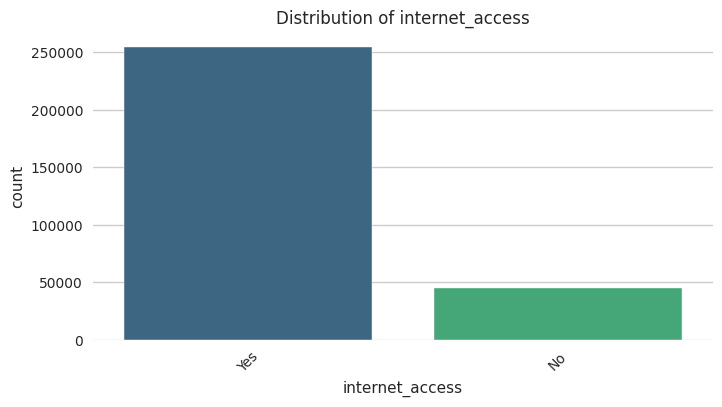

/tmp/ipykernel_28261/386563438.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


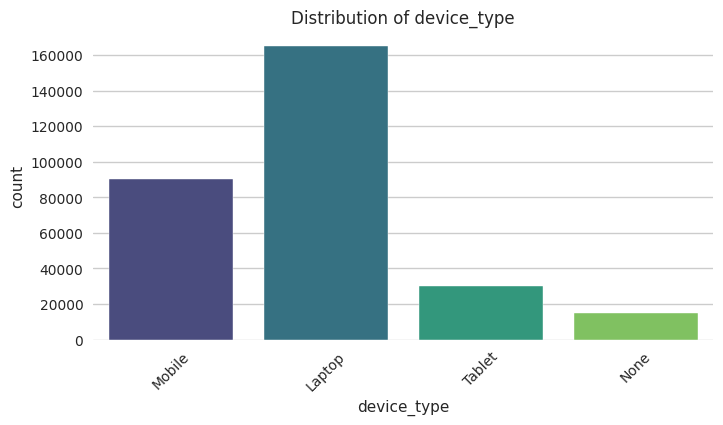

/tmp/ipykernel_28261/386563438.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


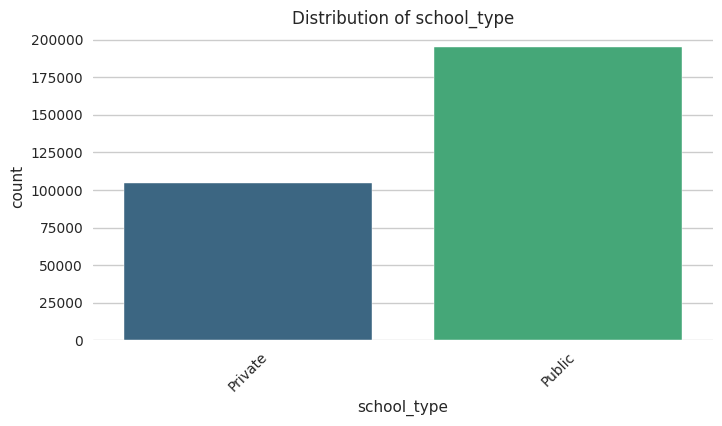

/tmp/ipykernel_28261/386563438.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


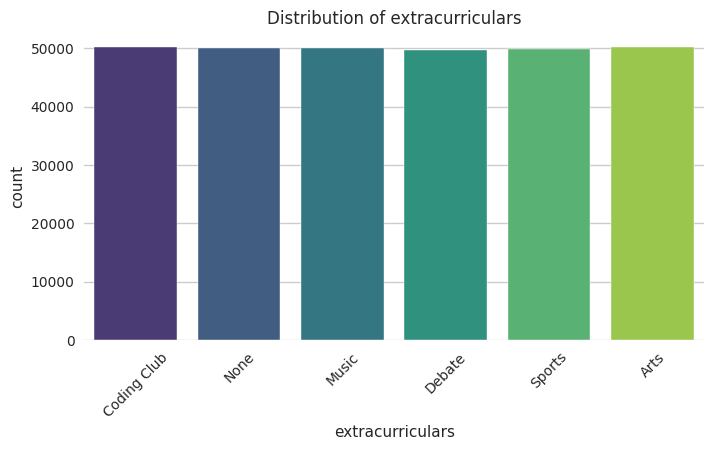

/tmp/ipykernel_28261/386563438.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


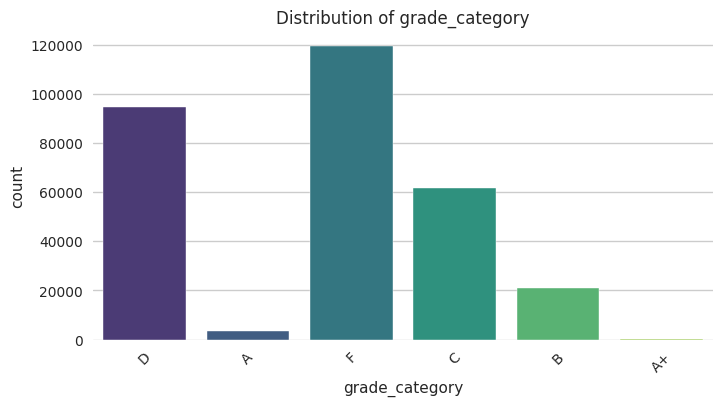

In [10]:
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

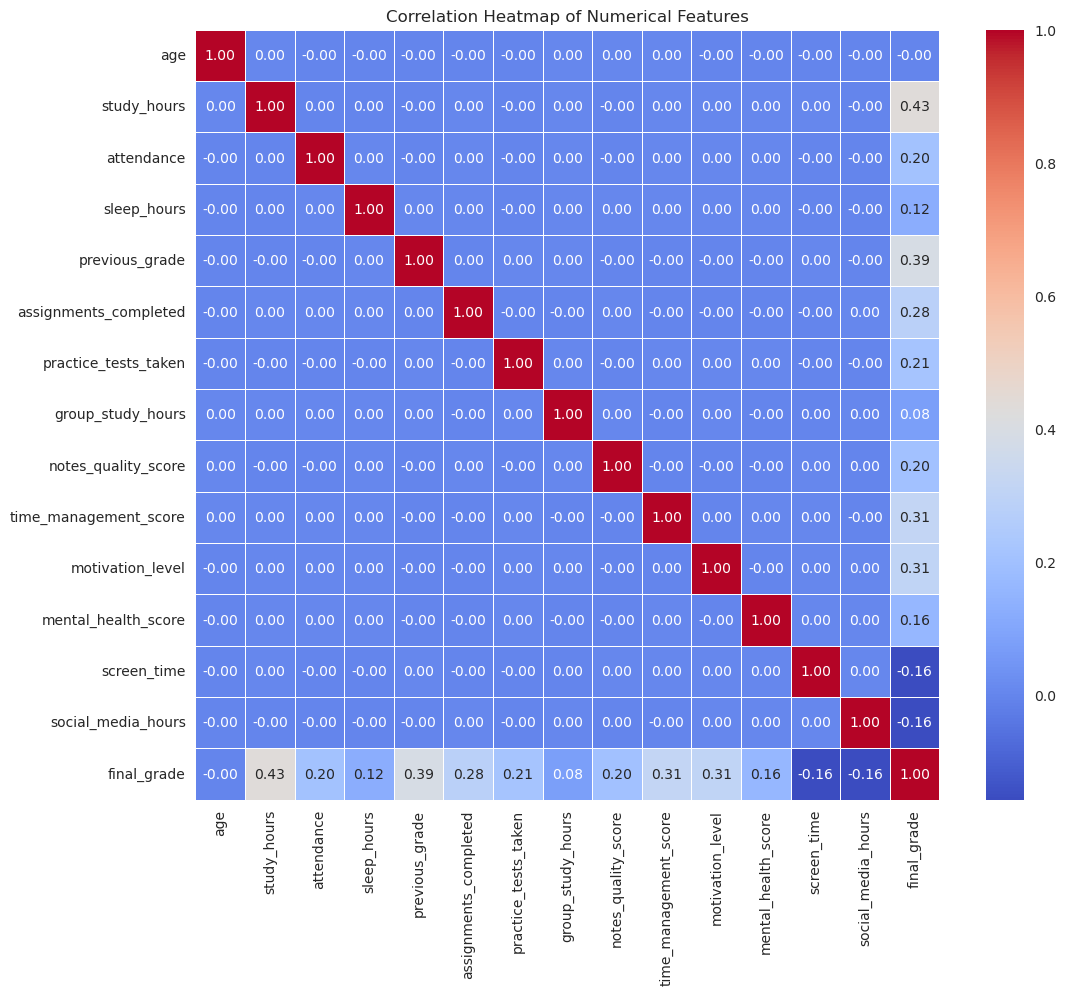

In [74]:
plt.figure(figsize=(12,10))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

/tmp/ipykernel_28261/3680504449.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pass_fail', y=col, palette='Set2')


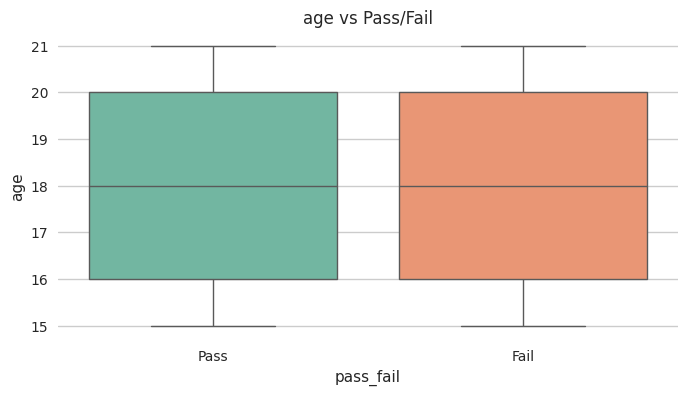

/tmp/ipykernel_28261/3680504449.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pass_fail', y=col, palette='Set2')


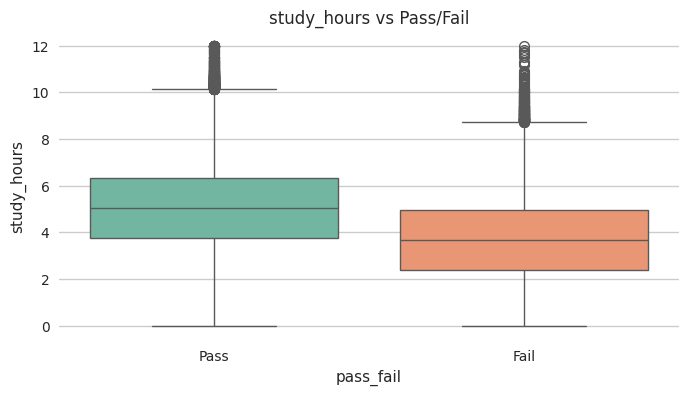

/tmp/ipykernel_28261/3680504449.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pass_fail', y=col, palette='Set2')


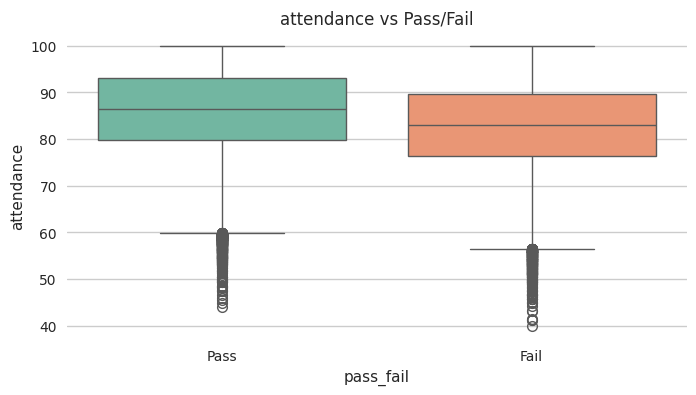

/tmp/ipykernel_28261/3680504449.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pass_fail', y=col, palette='Set2')


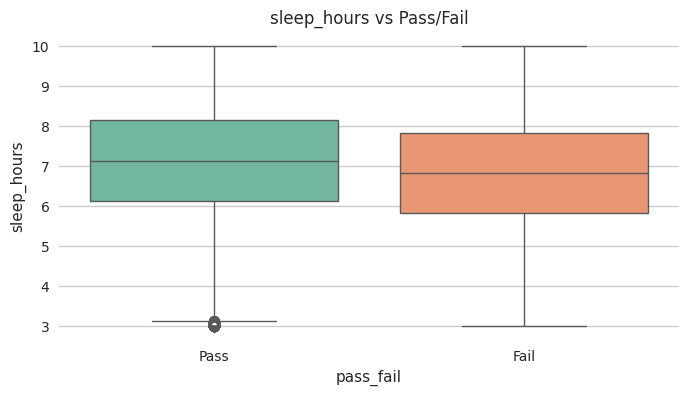

/tmp/ipykernel_28261/3680504449.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pass_fail', y=col, palette='Set2')


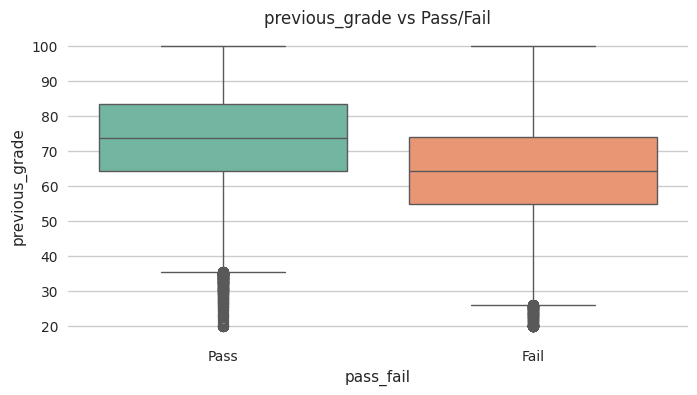

/tmp/ipykernel_28261/3680504449.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pass_fail', y=col, palette='Set2')


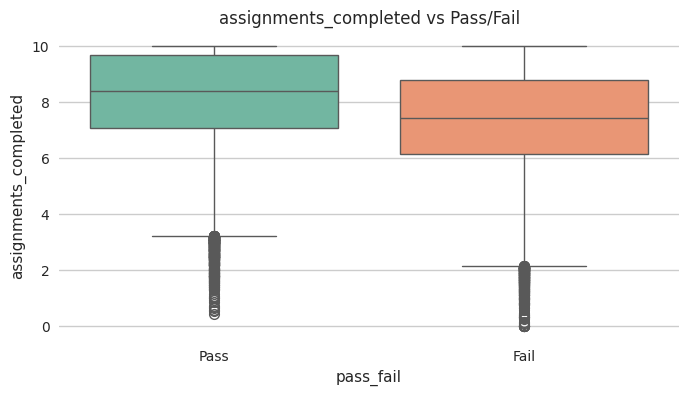

/tmp/ipykernel_28261/3680504449.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pass_fail', y=col, palette='Set2')


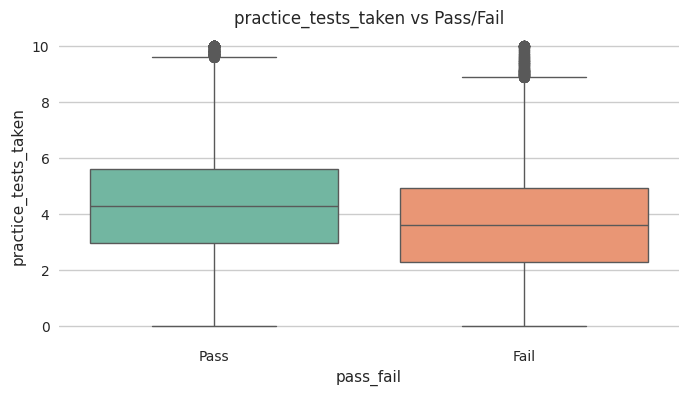

/tmp/ipykernel_28261/3680504449.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pass_fail', y=col, palette='Set2')


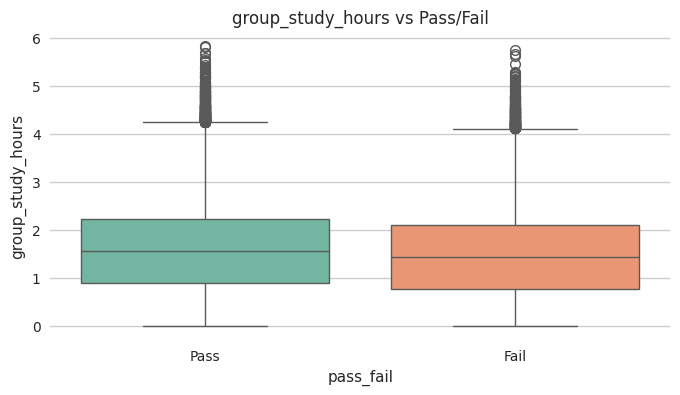

/tmp/ipykernel_28261/3680504449.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pass_fail', y=col, palette='Set2')


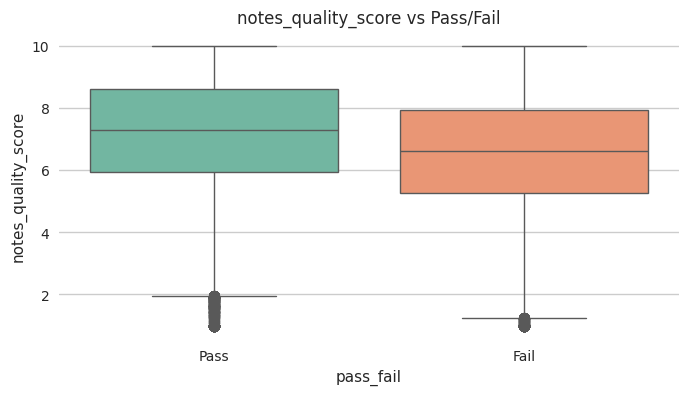

/tmp/ipykernel_28261/3680504449.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pass_fail', y=col, palette='Set2')


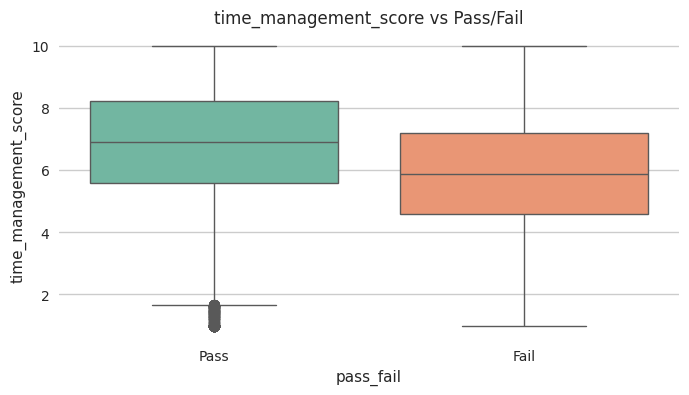

/tmp/ipykernel_28261/3680504449.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pass_fail', y=col, palette='Set2')


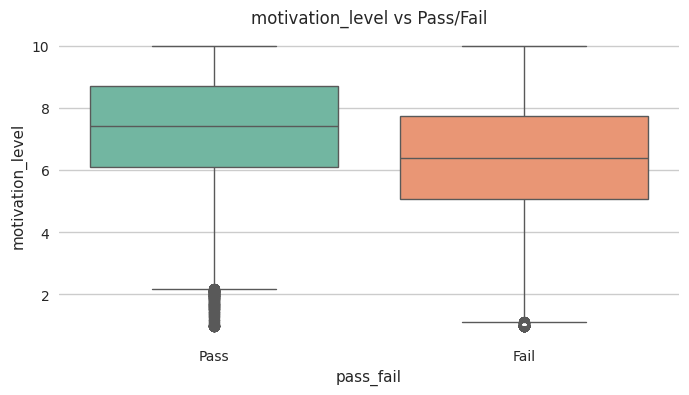

/tmp/ipykernel_28261/3680504449.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pass_fail', y=col, palette='Set2')


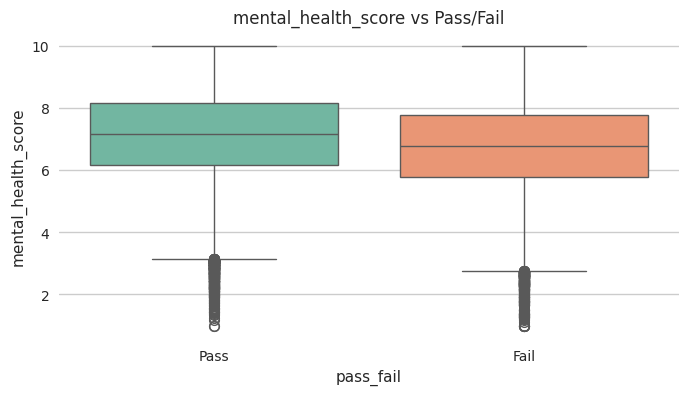

/tmp/ipykernel_28261/3680504449.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pass_fail', y=col, palette='Set2')


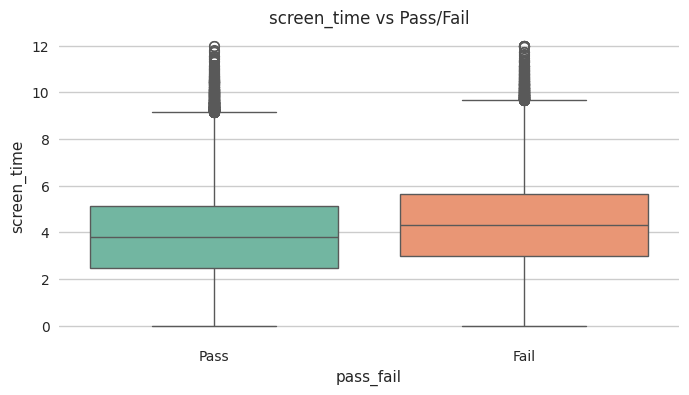

/tmp/ipykernel_28261/3680504449.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pass_fail', y=col, palette='Set2')


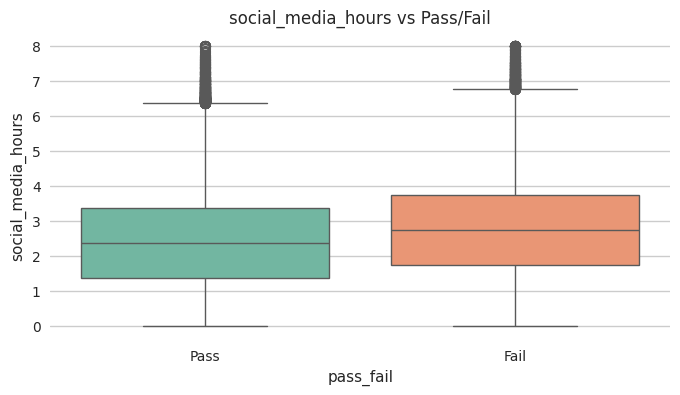

/tmp/ipykernel_28261/3680504449.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pass_fail', y=col, palette='Set2')


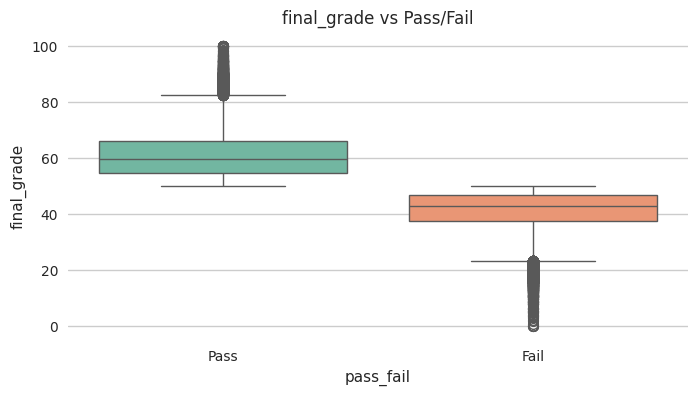

In [11]:
for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df, x='pass_fail', y=col, palette='Set2')
    plt.title(f'{col} vs Pass/Fail')
    plt.show()

In [12]:
print("Average values by Pass/Fail:")
print(df.groupby('pass_fail')[numerical_cols].mean().round(2))

Average values by Pass/Fail:
            age  study_hours  attendance  sleep_hours  previous_grade  \
pass_fail                                                               
Fail      18.00         3.68       82.82         6.81           64.23   
Pass      18.00         5.05       85.94         7.11           73.55   

           assignments_completed  practice_tests_taken  group_study_hours  \
pass_fail                                                                   
Fail                        7.36                  3.62               1.46   
Pass                        8.15                  4.28               1.58   

           notes_quality_score  time_management_score  motivation_level  \
pass_fail                                                                 
Fail                      6.57                   5.88              6.38   
Pass                      7.19                   6.85              7.32   

           mental_health_score  screen_time  social_media_hours  fin

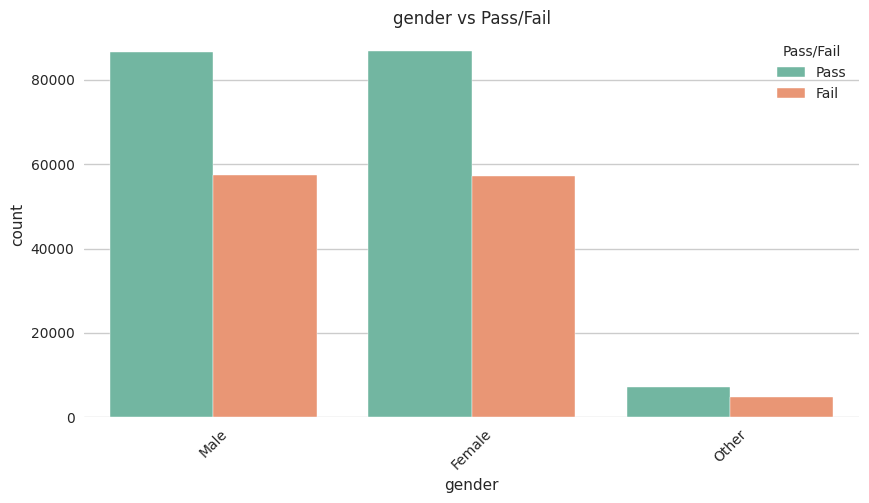

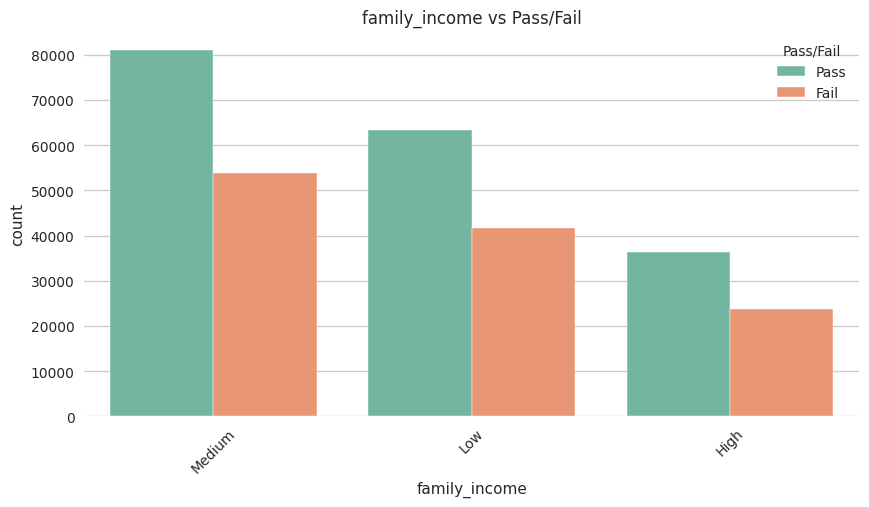

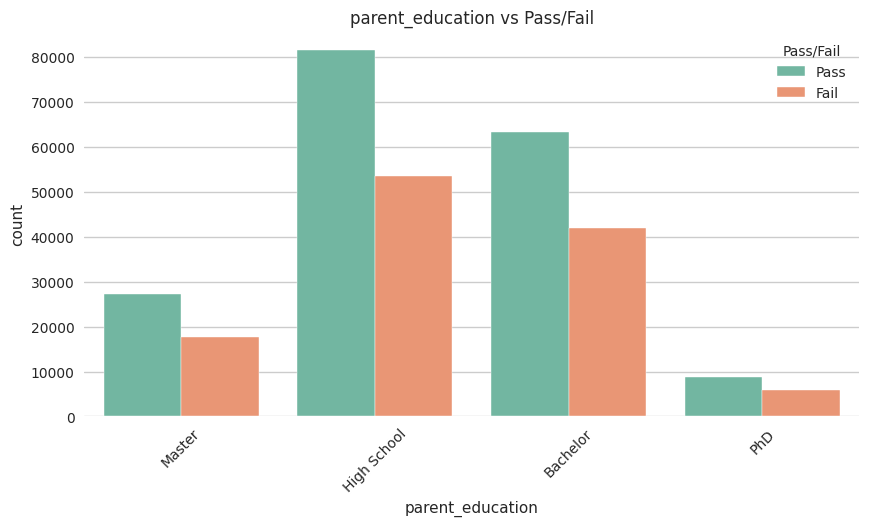

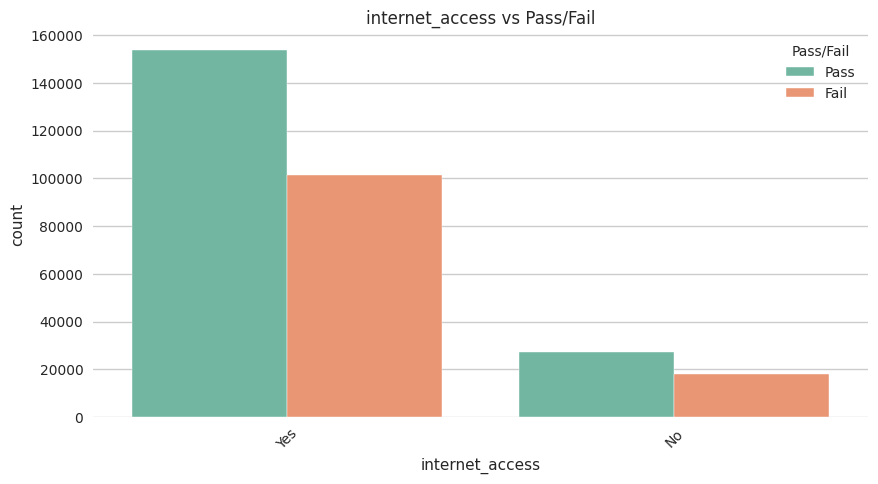

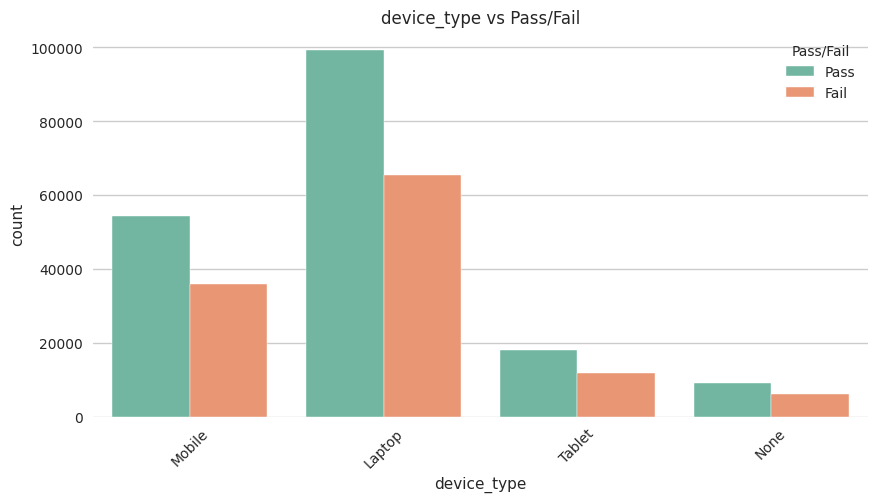

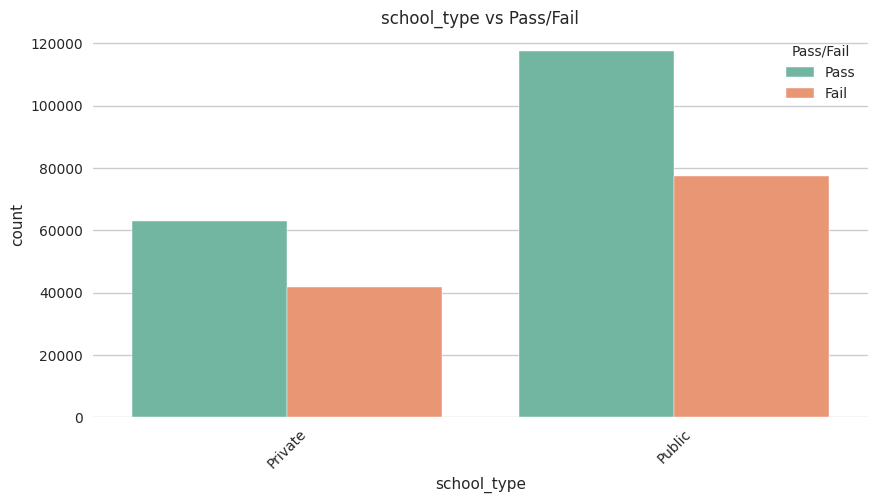

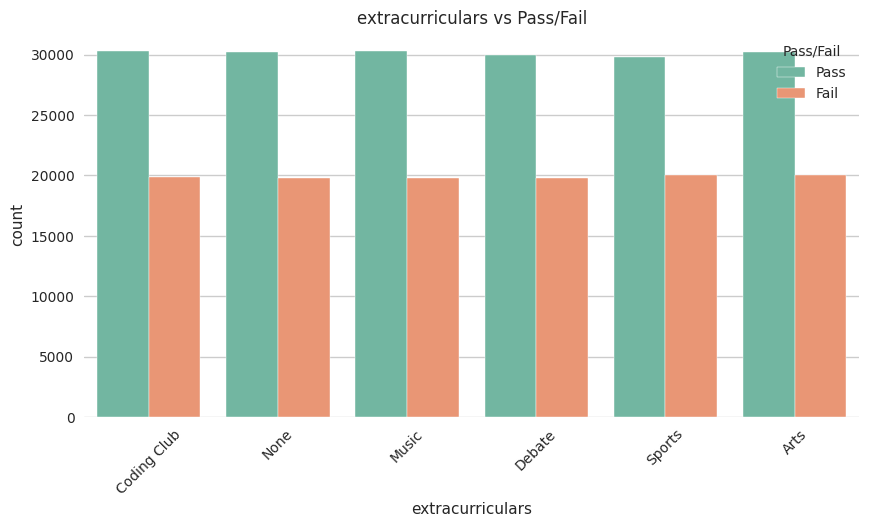

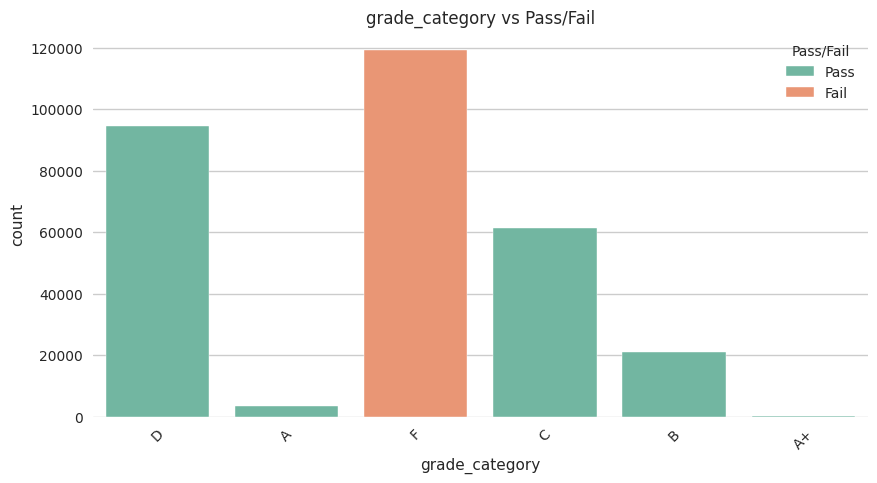

In [13]:
for col in categorical_cols:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x=col, hue='pass_fail', palette='Set2')
    plt.title(f'{col} vs Pass/Fail')
    plt.xticks(rotation=45)
    plt.legend(title='Pass/Fail')
    plt.show()

In [14]:
means = df.groupby('pass_fail')[numerical_cols].mean()
diff = (means.loc['Pass'] - means.loc['Fail']).abs().sort_values(ascending=False)
print("Features with biggest difference between Pass and Fail:\n", diff.head(10))

Features with biggest difference between Pass and Fail:
 final_grade             19.73
previous_grade           9.32
attendance               3.12
study_hours              1.36
time_management_score    0.98
motivation_level         0.94
assignments_completed    0.80
practice_tests_taken     0.67
notes_quality_score      0.62
screen_time              0.50
dtype: float64


In [15]:
df.head()

,student_id,age,gender,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,notes_quality_score,time_management_score,motivation_level,mental_health_score,screen_time,social_media_hours,family_income,parent_education,internet_access,device_type,school_type,extracurriculars,final_grade,grade_category,pass_fail
0,1,21,Male,1.65,79.15,8.23,96.05,7.72,1.87,1.45,6.81,7.32,9.05,7.76,1.55,4.02,Medium,Master,Yes,Mobile,Private,Coding Club,59.25,D,Pass
1,2,18,Male,4.46,72.53,6.14,53.02,6.75,5.63,1.89,10.00,10.00,9.81,4.23,5.46,3.27,Medium,Master,Yes,Laptop,Public,None,58.60,D,Pass
2,3,19,Female,6.22,98.53,6.95,78.78,10.00,7.86,1.77,6.48,3.62,10.00,7.58,0.00,2.33,Low,High School,Yes,Tablet,Private,Music,85.86,A,Pass
3,4,21,Female,1.83,97.73,8.30,76.12,7.44,2.32,1.20,6.06,5.37,5.94,4.98,5.33,1.16,Medium,Bachelor,Yes,Laptop,Public,Debate,42.12,F,Fail
4,5,17,Male,3.79,78.59,6.78,81.31,9.96,5.34,1.40,9.01,5.61,5.43,5.68,4.42,0.41,High,High School,Yes,Laptop,Private,Debate,62.87,C,Pass


In [16]:
# 2. Convert target to 0/1
print("Before mapping, pass_fail unique values:", df['pass_fail'].unique())
df['pass_fail'] = df['pass_fail'].map({'Pass': 1, 'Fail': 0})
print("After mapping, pass_fail unique values:", df['pass_fail'].unique())

# 3. All categorical columns
categorical_cols = ['gender', 'family_income', 'parent_education', 'internet_access', 'device_type',
                    'school_type', 'extracurriculars']

# 4. One-hot encode
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 5. Features and target
X = df_encoded.drop(columns=['pass_fail', 'final_grade', 'grade_category'])
y = df_encoded['pass_fail']

Before mapping, pass_fail unique values: ['Pass' 'Fail']
After mapping, pass_fail unique values: [1 0]


In [17]:
X.head()

,student_id,age,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,notes_quality_score,time_management_score,motivation_level,mental_health_score,screen_time,social_media_hours,gender_Male,gender_Other,family_income_Low,family_income_Medium,parent_education_High School,parent_education_Master,parent_education_PhD,internet_access_Yes,device_type_Mobile,device_type_None,device_type_Tablet,school_type_Public,extracurriculars_Coding Club,extracurriculars_Debate,extracurriculars_Music,extracurriculars_None,extracurriculars_Sports
0,1,21,1.65,79.15,8.23,96.05,7.72,1.87,1.45,6.81,7.32,9.05,7.76,1.55,4.02,True,False,False,True,False,True,False,True,True,False,False,False,True,False,False,False,False
1,2,18,4.46,72.53,6.14,53.02,6.75,5.63,1.89,10.00,10.00,9.81,4.23,5.46,3.27,True,False,False,True,False,True,False,True,False,False,False,True,False,False,False,True,False
2,3,19,6.22,98.53,6.95,78.78,10.00,7.86,1.77,6.48,3.62,10.00,7.58,0.00,2.33,False,False,True,False,True,False,False,True,False,False,True,False,False,False,True,False,False
3,4,21,1.83,97.73,8.30,76.12,7.44,2.32,1.20,6.06,5.37,5.94,4.98,5.33,1.16,False,False,False,True,False,False,False,True,False,False,False,True,False,True,False,False,False
4,5,17,3.79,78.59,6.78,81.31,9.96,5.34,1.40,9.01,5.61,5.43,5.68,4.42,0.41,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False


In [18]:
y.head()

0    1
1    1
2    1
3    0
4    1
Name: pass_fail, dtype: int64

In [19]:
X.shape

(300000, 32)

In [20]:
y.shape

(300000,)

In [21]:
y.isnull()

0         False
1         False
2         False
3         False
4         False
          ...  
299995    False
299996    False
299997    False
299998    False
299999    False
Name: pass_fail, Length: 300000, dtype: bool

In [22]:
#Drop useless column
df_encoded = df_encoded.drop(columns=['student_id'])
X=X.drop(columns=['student_id'])

In [23]:
df_encoded.head()

,age,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,notes_quality_score,time_management_score,motivation_level,mental_health_score,screen_time,social_media_hours,final_grade,grade_category,pass_fail,gender_Male,gender_Other,family_income_Low,family_income_Medium,parent_education_High School,parent_education_Master,parent_education_PhD,internet_access_Yes,device_type_Mobile,device_type_None,device_type_Tablet,school_type_Public,extracurriculars_Coding Club,extracurriculars_Debate,extracurriculars_Music,extracurriculars_None,extracurriculars_Sports
0,21,1.65,79.15,8.23,96.05,7.72,1.87,1.45,6.81,7.32,9.05,7.76,1.55,4.02,59.25,D,1,True,False,False,True,False,True,False,True,True,False,False,False,True,False,False,False,False
1,18,4.46,72.53,6.14,53.02,6.75,5.63,1.89,10.00,10.00,9.81,4.23,5.46,3.27,58.60,D,1,True,False,False,True,False,True,False,True,False,False,False,True,False,False,False,True,False
2,19,6.22,98.53,6.95,78.78,10.00,7.86,1.77,6.48,3.62,10.00,7.58,0.00,2.33,85.86,A,1,False,False,True,False,True,False,False,True,False,False,True,False,False,False,True,False,False
3,21,1.83,97.73,8.30,76.12,7.44,2.32,1.20,6.06,5.37,5.94,4.98,5.33,1.16,42.12,F,0,False,False,False,True,False,False,False,True,False,False,False,True,False,True,False,False,False
4,17,3.79,78.59,6.78,81.31,9.96,5.34,1.40,9.01,5.61,5.43,5.68,4.42,0.41,62.87,C,1,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False


In [24]:
X.head()

,age,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,notes_quality_score,time_management_score,motivation_level,mental_health_score,screen_time,social_media_hours,gender_Male,gender_Other,family_income_Low,family_income_Medium,parent_education_High School,parent_education_Master,parent_education_PhD,internet_access_Yes,device_type_Mobile,device_type_None,device_type_Tablet,school_type_Public,extracurriculars_Coding Club,extracurriculars_Debate,extracurriculars_Music,extracurriculars_None,extracurriculars_Sports
0,21,1.65,79.15,8.23,96.05,7.72,1.87,1.45,6.81,7.32,9.05,7.76,1.55,4.02,True,False,False,True,False,True,False,True,True,False,False,False,True,False,False,False,False
1,18,4.46,72.53,6.14,53.02,6.75,5.63,1.89,10.00,10.00,9.81,4.23,5.46,3.27,True,False,False,True,False,True,False,True,False,False,False,True,False,False,False,True,False
2,19,6.22,98.53,6.95,78.78,10.00,7.86,1.77,6.48,3.62,10.00,7.58,0.00,2.33,False,False,True,False,True,False,False,True,False,False,True,False,False,False,True,False,False
3,21,1.83,97.73,8.30,76.12,7.44,2.32,1.20,6.06,5.37,5.94,4.98,5.33,1.16,False,False,False,True,False,False,False,True,False,False,False,True,False,True,False,False,False
4,17,3.79,78.59,6.78,81.31,9.96,5.34,1.40,9.01,5.61,5.43,5.68,4.42,0.41,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False


In [25]:
# 6. Save for later use
X.to_csv('X_features.csv', index=False)
y.to_csv('y_target.csv', index=False)
df_encoded.to_csv('cleaned_student_performance_dataset.csv', index=False)

print("\nAll cleaned data saved successfully!")


All cleaned data saved successfully!
